# Gapminder 2: Scatterplots and Trends
**ENGR 1451 / 2451 · Exploratory Data Analytics**

**Focus:** scatterplots → log scales and groups → time-series plots → bubble plot → save.

Keep `data/gapminder.csv` beside this notebook in a `data` folder. Run the setup below even
after completing Part 1: this notebook runs independently. Restart the kernel and run all
cells before saving your work. The exercise is left for you to complete.

Each row is a **country–year observation** from 1952–2007. `lifeExp` is life expectancy in years,
`gdpPercap` is GDP per capita in inflation-adjusted US dollars, and `pop` is population.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

%matplotlib inline
gapminder = pd.read_csv(Path("data/gapminder.csv"))
gap_2007 = gapminder.loc[gapminder["year"] == 2007].copy()

## 1. Start with a scatterplot
Each dot below represents one country–year, pooling all years.
`fig` is the complete figure; `ax` is the plotting area.

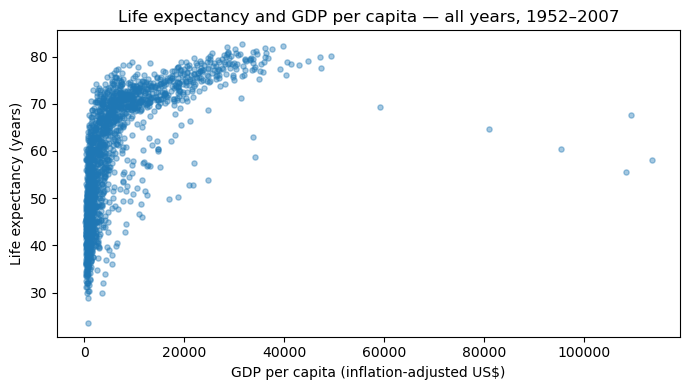

In [2]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(gapminder["gdpPercap"], gapminder["lifeExp"], s=14, alpha=0.4)
ax.set(
    xlabel="GDP per capita (inflation-adjusted US$)",
    ylabel="Life expectancy (years)",
    title="Life expectancy and GDP per capita — all years, 1952–2007",
)
fig.tight_layout()
plt.show()

## 2. Use a log axis and distinguish continents
`set_xscale("log")` changes the axis, not the stored data. Equal distances represent equal
**ratios**, not equal dollar differences. `alpha` controls transparency; the loop plots one continent at a time.

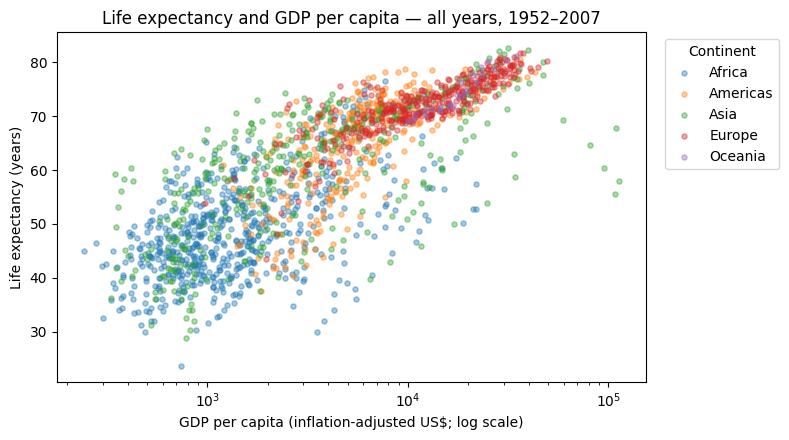

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for continent, group in gapminder.groupby("continent", sort=True):
    ax.scatter(
        group["gdpPercap"], group["lifeExp"],
        s=14, alpha=0.4, label=continent,
    )
ax.set_xscale("log")
ax.set(
    xlabel="GDP per capita (inflation-adjusted US$; log scale)",
    ylabel="Life expectancy (years)",
    title="Life expectancy and GDP per capita — all years, 1952–2007",
)
ax.legend(title="Continent", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

## 3. Follow countries over time
Select countries with `.isin()` and sort each country's observations by year before connecting them.
The legend is ordered by life expectancy in 2007. Identify the intervals with the sharpest decreases;
the lines connect five-year observations, not annual measurements.

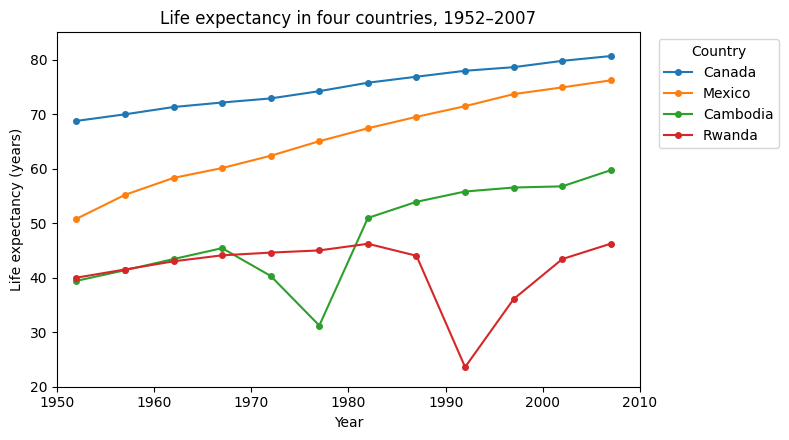

In [4]:
selected_countries = ["Canada", "Rwanda", "Cambodia", "Mexico"]
four_countries = gapminder.loc[gapminder["country"].isin(selected_countries)]
legend_order = (
    four_countries.loc[four_countries["year"] == 2007]
    .sort_values("lifeExp", ascending=False)["country"]
)

fig, ax = plt.subplots(figsize=(8, 4.5))
for country in legend_order:
    group = four_countries.loc[four_countries["country"] == country].sort_values("year")
    ax.plot(group["year"], group["lifeExp"], marker="o", markersize=4, label=country)
ax.set(
    xlabel="Year", ylabel="Life expectancy (years)",
    title="Life expectancy in four countries, 1952–2007",
    xlim=(1950, 2010), ylim=(20, 85),
)
ax.legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

## 4. Summarize first, then plot
Each point is the **unweighted country mean for one continent and year**.
These lines summarize multiple countries; they are not population-weighted estimates or fitted trends.

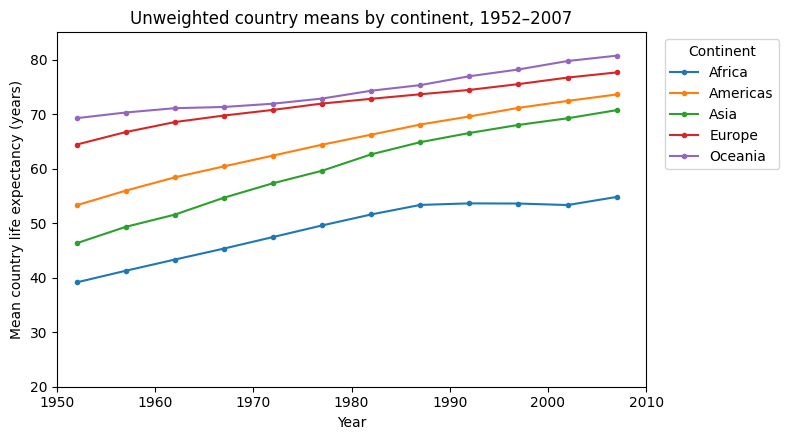

In [5]:
continent_trends = (
    gapminder.groupby(["continent", "year"], as_index=False)
    .agg(mean_life_exp=("lifeExp", "mean"))
)

fig, ax = plt.subplots(figsize=(8, 4.5))
for continent, group in continent_trends.groupby("continent", sort=True):
    group = group.sort_values("year")
    ax.plot(group["year"], group["mean_life_exp"], marker="o", markersize=3, label=continent)
ax.set(
    xlabel="Year", ylabel="Mean country life expectancy (years)",
    title="Unweighted country means by continent, 1952–2007",
    xlim=(1950, 2010), ylim=(20, 85),
)
ax.legend(title="Continent", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

## 5. Map population to bubble area
Use **2007 only**. The `s` argument controls marker area in points squared:
`s = pop / population_scale` makes area proportional to population. Do not take a square root here.
The legends identify continents and population sizes. A positive association does not establish causation.

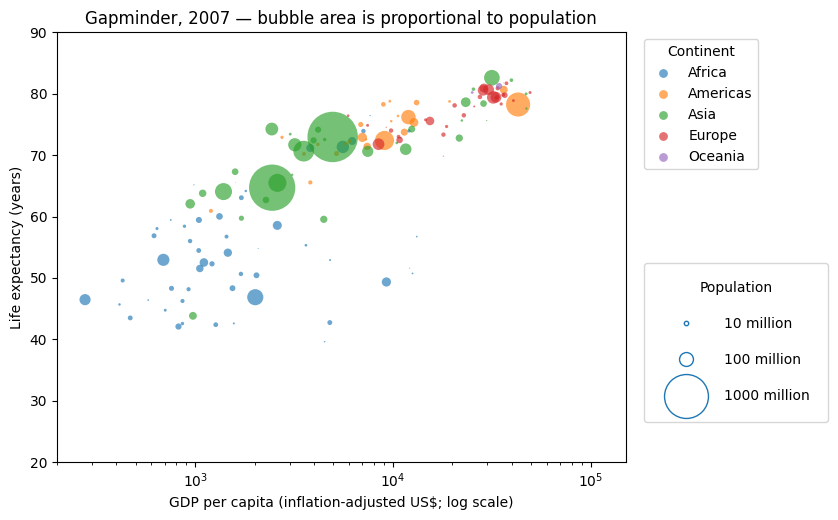

In [6]:
# Larger countries are drawn first within each continent.
population_scale = 1_000_000
bubble_fig, ax = plt.subplots(figsize=(8.5, 5.3))
for continent, group in gap_2007.groupby("continent", sort=True):
    group = group.sort_values("pop", ascending=False)
    ax.scatter(
        group["gdpPercap"], group["lifeExp"],
        s=group["pop"] / population_scale,
        alpha=0.65, linewidths=0, label=continent,
    )
ax.set_xscale("log")
ax.set(
    xlabel="GDP per capita (inflation-adjusted US$; log scale)",
    ylabel="Life expectancy (years)",
    title="Gapminder, 2007 — bubble area is proportional to population",
    xlim=(200, 150_000), ylim=(20, 90),
)

# Give the category legend uniform marker sizes.
continent_legend = ax.legend(
    title="Continent", bbox_to_anchor=(1.02, 1), loc="upper left",
)
for handle in continent_legend.legend_handles:
    handle.set_sizes([40])
ax.add_artist(continent_legend)

# The square root is appropriate here because Line2D takes a linear marker size.
size_handles = [
    Line2D([], [], linestyle="none", marker="o", fillstyle="none",
           markersize=np.sqrt(population / population_scale),
           label=f"{population / 1_000_000:g} million")
    for population in [10_000_000, 100_000_000, 1_000_000_000]
]
ax.legend(
    handles=size_handles, title="Population", labelspacing=1.6,
    handlelength=3.5, borderpad=1.3, handletextpad=1.0,
    bbox_to_anchor=(1.02, 0.48), loc="upper left",
)
bubble_fig.tight_layout()
plt.show()

### Exercise 2 — Make a fair comparison across years
Create the same bubble plot for **1952**, keeping the same x- and y-axis limits and
`population_scale`. Describe one change in the GDP–life-expectancy pattern and one change in
bubble sizes between 1952 and 2007. Why would rescaling bubbles separately for each year
make the comparison misleading?

In [7]:
# Your code here. Use a new figure variable; keep bubble_fig for the 2007 export below.

**Your interpretation:**

_Write two or three sentences here._

## 6. Save the figure
`bbox_inches="tight"` includes the outside legends. Rerunning this cell replaces the generated PNG.

In [8]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)
figure_path = output_dir / "gapminder_bubble_2007.png"
bubble_fig.savefig(figure_path, dpi=200, bbox_inches="tight")
print(f"Saved: {figure_path}")

Saved: outputs/gapminder_bubble_2007.png


---
## Command reference
| Task | Python pattern |
|:--|:--|
| Select several countries | `df["country"].isin(["Canada", "Mexico"])` |
| Create a figure | `fig, ax = plt.subplots(figsize=(7, 4))` |
| Scatterplot | `ax.scatter(x, y, s=20, alpha=0.4)` |
| Logarithmic axis | `ax.set_xscale("log")` |
| Line plot | `ax.plot(year, life_exp)` after sorting by year |
| Labels and title | `ax.set(xlabel="...", ylabel="...", title="...")` |
| Bubble area | `ax.scatter(x, y, s=population / population_scale)` |
| Save a figure | `fig.savefig(path, dpi=200, bbox_inches="tight")` |

**Source:** Selected Python adaptation of the supplied *Gapminder EDA–ggplot2* tutorial,
credited to Jenny Bryan and modified by Roger French. The country-mean trend is an added
descriptive summary retained from the original Python notebook. See Part 1 for CSV provenance.